# IPL Win Probability Prediction (Second Innings)
Predicts the probability of the chasing team winning based on live match situation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, log_loss
)
from xgboost import XGBClassifier
import pickle

## Step 1: Load and Preprocess Data (Same as Score Prediction Notebook)

In [3]:
# Load raw data
df = pd.read_csv("../data/IPL.csv", low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (278205, 64)


,Unnamed: 0,match_id,date,Unnamed: 3,Unnamed: 4,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,18-04-2008,NaN,NaN,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,18-04-2008,NaN,NaN,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,18-04-2008,NaN,NaN,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,18-04-2008,NaN,NaN,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,18-04-2008,NaN,NaN,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [4]:
# ── Same team name mapping as score-prediction notebook ──
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}
df['batting_team'] = df['batting_team'].replace(team_mapping)
df['bowling_team'] = df['bowling_team'].replace(team_mapping)

# ── Remove old / defunct teams ──
old_teams = [
    'Deccan Chargers', 'Kochi Tuskers Kerala',
    'Pune Warriors', 'Gujarat Lions', 'Rising Pune Supergiants'
]
df = df[~df['batting_team'].isin(old_teams)]
df = df[~df['bowling_team'].isin(old_teams)]

# ── Same venue cleaning as score-prediction notebook ──
df['venue'] = df['venue'].str.split(',').str[0]

venue_mapping = {
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'Punjab Cricket Association IS Bindra Stadium': 'Punjab Cricket Association Stadium',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium': 'ACA-VDCA Cricket Stadium',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium'
}
df['venue'] = df['venue'].replace(venue_mapping)

# ── Parse date and year ──
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

print("Teams:", sorted(df['batting_team'].unique()))
print("Total teams:", df['batting_team'].nunique())
print("Total venues:", df['venue'].nunique())

Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']
Total teams: 10
Total venues: 35


## Step 2: Build Match-Level Summary
For win prediction we need to know who batted first, their score, and who won.

In [5]:
# ── First innings: batting team and final score ──
first_innings = (
    df[df['innings'] == 1]
    .groupby('match_id')
    .agg(
        batting_team_1st=('batting_team', 'first'),
        bowling_team_1st=('bowling_team', 'first'),
        venue=('venue', 'first'),
        date=('date', 'first'),
        year=('year', 'first'),
        first_innings_score=('team_runs', 'max')
    )
    .reset_index()
)

# ── Second innings: chasing team final score ──
second_innings = (
    df[df['innings'] == 2]
    .groupby('match_id')
    .agg(
        batting_team_2nd=('batting_team', 'first'),
        second_innings_score=('team_runs', 'max')
    )
    .reset_index()
)

# ── Match winner info from match_won_by column ──
match_info = (
    df[['match_id', 'match_won_by', 'result_type']]
    .drop_duplicates('match_id')
)

# ── Merge everything ──
matches = first_innings.merge(second_innings, on='match_id')
matches = matches.merge(match_info, on='match_id')

# ── Target for second innings ──
matches['target'] = matches['first_innings_score'] + 1

# ── Did the chasing team (2nd innings batting team) win? ──
matches['chasing_team_won'] = (
    matches['match_won_by'] == matches['batting_team_2nd']
).astype(int)

# ── Drop ties/no result ──
matches = matches[matches['result_type'] != 'no result']
matches = matches[matches['result_type'] != 'tie']
matches = matches.dropna(subset=['match_won_by'])

print("Total matches:", len(matches))
print("Chasing team win rate:", round(matches['chasing_team_won'].mean() * 100, 2), "%")
matches.head()

Total matches: 963
Chasing team win rate: 41.43 %


,match_id,batting_team_1st,bowling_team_1st,venue,date,year,first_innings_score,batting_team_2nd,second_innings_score,match_won_by,result_type,target,chasing_team_won
0,335982,Kolkata Knight Riders,Royal Challengers Bengaluru,M Chinnaswamy Stadium,2008-04-18,2008,222,Royal Challengers Bengaluru,82,Kolkata Knight Riders,NaN,223,0
1,335983,Chennai Super Kings,Punjab Kings,Punjab Cricket Association Stadium,2008-04-19,2008,240,Punjab Kings,207,Chennai Super Kings,NaN,241,0
2,335984,Rajasthan Royals,Delhi Capitals,Arun Jaitley Stadium,2008-04-19,2008,129,Delhi Capitals,132,Delhi Daredevils,NaN,130,0
3,335985,Mumbai Indians,Royal Challengers Bengaluru,Wankhede Stadium,2008-04-20,2008,165,Royal Challengers Bengaluru,166,Royal Challengers Bangalore,NaN,166,0
4,335987,Punjab Kings,Rajasthan Royals,Sawai Mansingh Stadium,2008-04-21,2008,166,Rajasthan Royals,168,Rajasthan Royals,NaN,167,1


## Step 3: Build Second Innings Ball-by-Ball Live Situation

In [6]:
# Keep only second innings, filter after over 5 for stable predictions
df2 = df[df['innings'] == 2].copy()

df2['overs_completed'] = df2['over'] + df2['ball'] / 6
df2['current_score']   = df2['team_runs']
df2['wickets_lost']    = df2['team_wicket']

# Keep only end-of-over snapshots
df2 = df2[df2['ball'] == 6].reset_index(drop=True)

# Merge target and match result
df2 = df2.merge(
    matches[['match_id', 'target', 'chasing_team_won',
             'batting_team_2nd', 'bowling_team_1st', 'venue', 'year']],
    on='match_id',
    how='inner'
)

# Use the already-clean columns from matches merge
df2['batting_team']  = df2['batting_team_2nd']
df2['bowling_team']  = df2['bowling_team_1st']
df2['venue']         = df2['venue_y']          # from matches
df2['year']          = df2['year_y']

# Filter after over 5 for stable predictions
df2 = df2[df2['overs_completed'] > 5]

# ── Derived features ──
df2['runs_required']     = (df2['target'] - df2['current_score']).clip(lower=0)
df2['balls_remaining']   = (120 - df2['overs_completed'] * 6).clip(lower=1)
df2['required_run_rate'] = (df2['runs_required'] / (df2['balls_remaining'] / 6)).round(4)
df2['current_run_rate']  = (df2['current_score'] / df2['overs_completed']).round(4)
df2['rrr_vs_crr']        = df2['required_run_rate'] - df2['current_run_rate']   # key pressure metric
df2['wickets_remaining'] = (10 - df2['wickets_lost']).clip(lower=0)

print("Second innings rows:", len(df2))
df2[['batting_team', 'bowling_team', 'venue', 'over',
     'current_score', 'target', 'runs_required',
     'balls_remaining', 'required_run_rate',
     'current_run_rate', 'rrr_vs_crr', 'chasing_team_won']].head()

Second innings rows: 13178


,batting_team,bowling_team,venue,over,current_score,target,runs_required,balls_remaining,required_run_rate,current_run_rate,rrr_vs_crr,chasing_team_won
5,Royal Challengers Bengaluru,Royal Challengers Bengaluru,M Chinnaswamy Stadium,5,26,223,197,84.0,14.0714,4.3333,9.7381,0
6,Royal Challengers Bengaluru,Royal Challengers Bengaluru,M Chinnaswamy Stadium,6,33,223,190,78.0,14.6154,4.7143,9.9011,0
7,Royal Challengers Bengaluru,Royal Challengers Bengaluru,M Chinnaswamy Stadium,7,38,223,185,72.0,15.4167,4.7500,10.6667,0
8,Royal Challengers Bengaluru,Royal Challengers Bengaluru,M Chinnaswamy Stadium,8,43,223,180,66.0,16.3636,4.7778,11.5858,0
9,Royal Challengers Bengaluru,Royal Challengers Bengaluru,M Chinnaswamy Stadium,9,51,223,172,60.0,17.2000,5.1000,12.1000,0


## Step 4: Feature Engineering — Venue Second Innings Averages

In [7]:
# Use last 3 seasons for venue averages (same logic as score prediction)
recent_matches = matches[matches['year'].isin([2023, 2024, 2025])]

# ── Venue second innings average score ──
venue_2nd_avg = (
    recent_matches.groupby('venue')['second_innings_score']
    .mean()
    .reset_index()
    .rename(columns={'second_innings_score': 'venue_2nd_innings_avg'})
)

# ── Venue chasing win rate (how easy is it to chase at this venue?) ──
venue_chase_rate = (
    recent_matches.groupby('venue')['chasing_team_won']
    .mean()
    .reset_index()
    .rename(columns={'chasing_team_won': 'venue_chase_win_rate'})
)

print("Venue 2nd innings avg:")
print(venue_2nd_avg.sort_values('venue_2nd_innings_avg', ascending=False).to_string(index=False))
print("\nVenue chasing win rate:")
print(venue_chase_rate.sort_values('venue_chase_win_rate', ascending=False).to_string(index=False))

Venue 2nd innings avg:
                                                       venue  venue_2nd_innings_avg
                                        Arun Jaitley Stadium             182.555556
                                                Eden Gardens             182.450000
                          Rajiv Gandhi International Stadium             181.944444
                Himachal Pradesh Cricket Association Stadium             181.200000
                                       M Chinnaswamy Stadium             179.842105
                                    ACA-VDCA Cricket Stadium             178.500000
                                            Wankhede Stadium             175.523810
                                       Narendra Modi Stadium             175.192308
                          Punjab Cricket Association Stadium             173.400000
                                      Sawai Mansingh Stadium             171.294118
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket 

## Step 5: Feature Engineering — Head-to-Head Win Ratio

In [8]:
# Head-to-head: chasing team vs defending team
# How often does the chasing team beat the defending team historically?

h2h = (
    matches.groupby(['batting_team_2nd', 'bowling_team_1st'])['chasing_team_won']
    .agg(['sum', 'count'])
    .reset_index()
)
h2h.columns = ['batting_team', 'bowling_team', 'h2h_wins', 'h2h_total']
h2h['h2h_win_ratio'] = (h2h['h2h_wins'] / h2h['h2h_total']).round(4)

# Fill teams with no h2h data with overall chasing win rate
overall_chase_rate = matches['chasing_team_won'].mean()
print(f"Overall chasing win rate (fallback): {overall_chase_rate:.4f}")
print("\nHead-to-Head sample:")
print(h2h.head(10).to_string(index=False))

Overall chasing win rate (fallback): 0.4143

Head-to-Head sample:
               batting_team                bowling_team  h2h_wins  h2h_total  h2h_win_ratio
        Chennai Super Kings         Chennai Super Kings        69        110         0.6273
             Delhi Capitals              Delhi Capitals        29        130         0.2231
             Gujarat Titans              Gujarat Titans        22         33         0.6667
      Kolkata Knight Riders       Kolkata Knight Riders        73        125         0.5840
       Lucknow Super Giants        Lucknow Super Giants        10         25         0.4000
             Mumbai Indians              Mumbai Indians        69        120         0.5750
               Punjab Kings                Punjab Kings        18        108         0.1667
           Rajasthan Royals            Rajasthan Royals        59        114         0.5175
Royal Challengers Bengaluru Royal Challengers Bengaluru         9        115         0.0783
        Sunris

## Step 6: Merge All Features into df2

In [9]:
# Merge venue second innings avg
df2 = df2.merge(venue_2nd_avg, on='venue', how='left')

# Merge venue chasing win rate
df2 = df2.merge(venue_chase_rate, on='venue', how='left')

# Merge head-to-head
df2 = df2.merge(
    h2h[['batting_team', 'bowling_team', 'h2h_win_ratio']],
    on=['batting_team', 'bowling_team'],
    how='left'
)

# Fill NaN with fallbacks
df2['venue_2nd_innings_avg']  = df2['venue_2nd_innings_avg'].fillna(df2['venue_2nd_innings_avg'].mean())
df2['venue_chase_win_rate']   = df2['venue_chase_win_rate'].fillna(overall_chase_rate)
df2['h2h_win_ratio']          = df2['h2h_win_ratio'].fillna(overall_chase_rate)

print("Shape after merging features:", df2.shape)
df2[['batting_team', 'bowling_team', 'venue',
     'venue_2nd_innings_avg', 'venue_chase_win_rate', 'h2h_win_ratio',
     'chasing_team_won']].head()

Shape after merging features: (13178, 84)


,batting_team,bowling_team,venue,venue_2nd_innings_avg,venue_chase_win_rate,h2h_win_ratio,chasing_team_won
0,Royal Challengers Bengaluru,Royal Challengers Bengaluru,M Chinnaswamy Stadium,179.842105,0.421053,0.0783,0
1,Royal Challengers Bengaluru,Royal Challengers Bengaluru,M Chinnaswamy Stadium,179.842105,0.421053,0.0783,0
2,Royal Challengers Bengaluru,Royal Challengers Bengaluru,M Chinnaswamy Stadium,179.842105,0.421053,0.0783,0
3,Royal Challengers Bengaluru,Royal Challengers Bengaluru,M Chinnaswamy Stadium,179.842105,0.421053,0.0783,0
4,Royal Challengers Bengaluru,Royal Challengers Bengaluru,M Chinnaswamy Stadium,179.842105,0.421053,0.0783,0


## Step 7: Prepare Feature Matrix

In [10]:
FEATURES = [
    'batting_team',
    'bowling_team',
    'venue',
    'overs_completed',
    'current_score',
    'wickets_lost',
    'wickets_remaining',
    'target',
    'runs_required',
    'balls_remaining',
    'required_run_rate',
    'current_run_rate',
    'rrr_vs_crr',                # pressure: RRR minus CRR
    'venue_2nd_innings_avg',     # venue 2nd innings scoring tendency
    'venue_chase_win_rate',      # how often chases succeed at this venue
    'h2h_win_ratio'              # head-to-head chasing team win ratio
]

X = df2[FEATURES].copy()
y = df2['chasing_team_won']

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['batting_team', 'bowling_team', 'venue'])

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print(f"Chasing win %: {y.mean()*100:.2f}%")

Feature matrix shape: (13178, 68)
Target distribution:
chasing_team_won
0    8018
1    5160
Name: count, dtype: int64
Chasing win %: 39.16%


## Step 8: Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (10542, 68)
Test size:  (2636, 68)


## Step 9: Train Random Forest Classifier

In [12]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds      = rf_model.predict(X_test)
rf_probs      = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Model Evaluation")
print("--------------------------------")
print(f"Accuracy  : {accuracy_score(y_test, rf_preds):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, rf_probs):.4f}")
print(f"Log Loss  : {log_loss(y_test, rf_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['Defending Wins', 'Chasing Wins']))

Random Forest Model Evaluation
--------------------------------
Accuracy  : 0.9522
ROC-AUC   : 0.9907
Log Loss  : 0.1676

Classification Report:
                precision    recall  f1-score   support

Defending Wins       0.96      0.96      0.96      1644
  Chasing Wins       0.94      0.94      0.94       992

      accuracy                           0.95      2636
     macro avg       0.95      0.95      0.95      2636
  weighted avg       0.95      0.95      0.95      2636



## Step 10: Train XGBoost Classifier

In [13]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Model Evaluation")
print("--------------------------")
print(f"Accuracy  : {accuracy_score(y_test, xgb_preds):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"Log Loss  : {log_loss(y_test, xgb_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds, target_names=['Defending Wins', 'Chasing Wins']))

XGBoost Model Evaluation
--------------------------
Accuracy  : 0.9465
ROC-AUC   : 0.9882
Log Loss  : 0.1654

Classification Report:
                precision    recall  f1-score   support

Defending Wins       0.96      0.95      0.96      1644
  Chasing Wins       0.93      0.93      0.93       992

      accuracy                           0.95      2636
     macro avg       0.94      0.94      0.94      2636
  weighted avg       0.95      0.95      0.95      2636



## Step 11: Model Comparison Chart

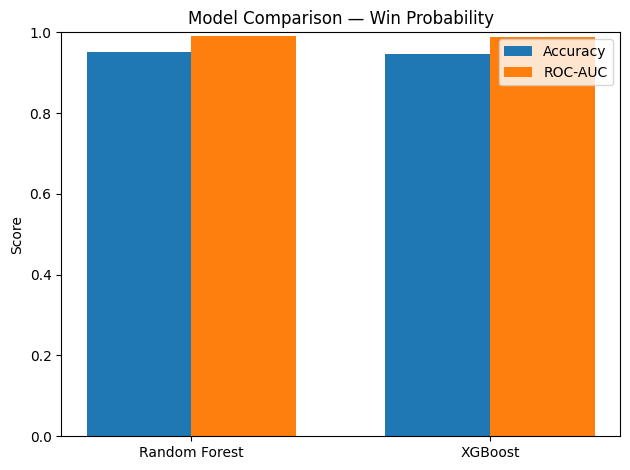

In [14]:
models  = ['Random Forest', 'XGBoost']
acc     = [accuracy_score(y_test, rf_preds), accuracy_score(y_test, xgb_preds)]
auc     = [roc_auc_score(y_test, rf_probs),  roc_auc_score(y_test, xgb_probs)]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, acc, width, label='Accuracy')
ax.bar(x + width/2, auc, width, label='ROC-AUC')

ax.set_title('Model Comparison — Win Probability')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

## Step 12: Confusion Matrix

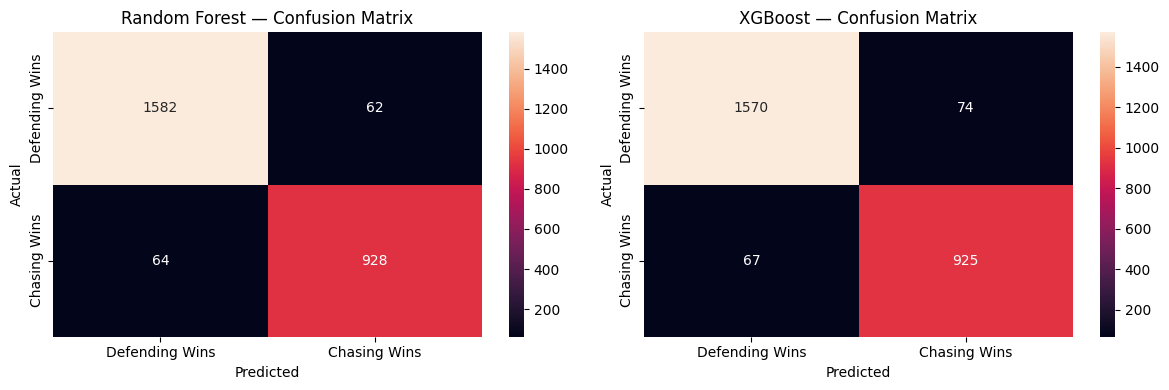

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [rf_preds, xgb_preds],
    ['Random Forest', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=['Defending Wins', 'Chasing Wins'],
        yticklabels=['Defending Wins', 'Chasing Wins']
    )
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Step 13: Feature Importance

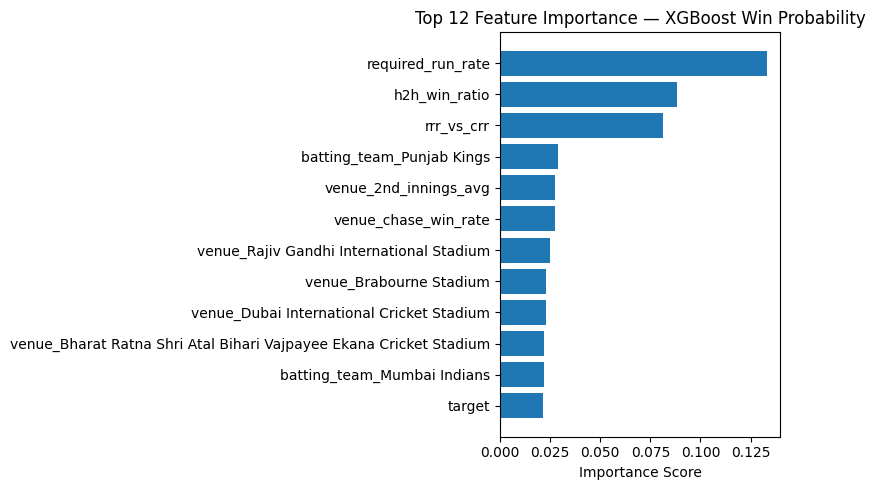

In [16]:
importance = xgb_model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Feature'][:12], feat_imp['Importance'][:12])
plt.title('Top 12 Feature Importance — XGBoost Win Probability')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 14: Grouped Feature Importance

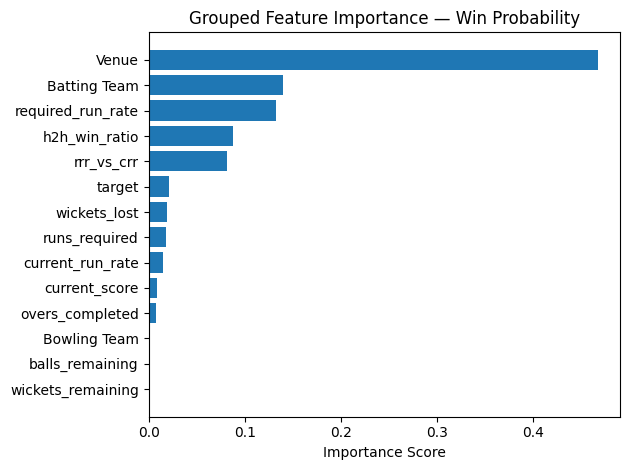

In [17]:
feat_imp['Group'] = feat_imp['Feature'].apply(
    lambda x:
        'Batting Team'  if x.startswith('batting_team')  else
        'Bowling Team'  if x.startswith('bowling_team')  else
        'Venue'         if x.startswith('venue_')        else
        x
)

grouped = (
    feat_imp.groupby('Group')['Importance']
    .sum()
    .reset_index()
    .sort_values('Importance', ascending=False)
)

plt.figure()
plt.barh(grouped['Group'], grouped['Importance'])
plt.title('Grouped Feature Importance — Win Probability')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 15: Save Best Model (XGBoost)

In [18]:
pickle.dump(xgb_model,   open('win_probability_model.pkl',   'wb'))
pickle.dump(X.columns,   open('win_model_columns.pkl',       'wb'))

# Also save the h2h and venue lookup tables for the prediction function
pickle.dump(h2h,              open('h2h_table.pkl',               'wb'))
pickle.dump(venue_2nd_avg,    open('venue_2nd_avg.pkl',           'wb'))
pickle.dump(venue_chase_rate, open('venue_chase_rate.pkl',        'wb'))

print("All files saved successfully!")

All files saved successfully!


## Step 16: Live Prediction Function

In [19]:
def predict_win_probability(
    batting_team, bowling_team, venue,
    target, current_score, wickets_lost, overs_completed
):
    """
    Predicts win probability for the chasing team.

    Parameters
    ----------
    batting_team   : str   — team currently batting (chasing)
    bowling_team   : str   — team bowling (defending)
    venue          : str   — stadium name
    target         : int   — runs required to win
    current_score  : int   — chasing team's current score
    wickets_lost   : int   — wickets fallen so far
    overs_completed: float — overs bowled so far (e.g. 10.0, 10.3)

    Returns
    -------
    dict with chasing_win_prob and defending_win_prob
    """

    runs_required     = max(target - current_score, 0)
    balls_remaining   = max(120 - overs_completed * 6, 1)
    required_run_rate = runs_required / (balls_remaining / 6)
    current_run_rate  = current_score / overs_completed if overs_completed > 0 else 0
    rrr_vs_crr        = required_run_rate - current_run_rate
    wickets_remaining = 10 - wickets_lost

    # Venue lookups
    v2_avg   = venue_2nd_avg.loc[venue_2nd_avg['venue'] == venue, 'venue_2nd_innings_avg']
    v_chase  = venue_chase_rate.loc[venue_chase_rate['venue'] == venue, 'venue_chase_win_rate']
    h2h_row  = h2h[(h2h['batting_team'] == batting_team) & (h2h['bowling_team'] == bowling_team)]

    venue_2nd_avg_val   = float(v2_avg.values[0])  if len(v2_avg)   > 0 else venue_2nd_avg['venue_2nd_innings_avg'].mean()
    venue_chase_val     = float(v_chase.values[0]) if len(v_chase)  > 0 else overall_chase_rate
    h2h_ratio           = float(h2h_row['h2h_win_ratio'].values[0]) if len(h2h_row) > 0 else overall_chase_rate

    input_df = pd.DataFrame([{
        'batting_team'       : batting_team,
        'bowling_team'       : bowling_team,
        'venue'              : venue,
        'overs_completed'    : overs_completed,
        'current_score'      : current_score,
        'wickets_lost'       : wickets_lost,
        'wickets_remaining'  : wickets_remaining,
        'target'             : target,
        'runs_required'      : runs_required,
        'balls_remaining'    : balls_remaining,
        'required_run_rate'  : round(required_run_rate, 4),
        'current_run_rate'   : round(current_run_rate, 4),
        'rrr_vs_crr'         : round(rrr_vs_crr, 4),
        'venue_2nd_innings_avg': venue_2nd_avg_val,
        'venue_chase_win_rate' : venue_chase_val,
        'h2h_win_ratio'        : h2h_ratio
    }])

    input_df = pd.get_dummies(input_df, columns=['batting_team', 'bowling_team', 'venue'])
    input_df = input_df.reindex(columns=win_model_columns, fill_value=0)

    prob = xgb_model.predict_proba(input_df)[0]
    chasing_win  = round(prob[1] * 100, 2)
    defending_win = round(prob[0] * 100, 2)

    print(f"\n{'='*45}")
    print(f"  {batting_team} (Chasing) vs {bowling_team}")
    print(f"  Venue        : {venue}")
    print(f"  Target       : {target}")
    print(f"  Score        : {current_score}/{wickets_lost} in {overs_completed} overs")
    print(f"  Need         : {runs_required} off {int(balls_remaining)} balls")
    print(f"  RRR          : {required_run_rate:.2f}  |  CRR: {current_run_rate:.2f}")
    print(f"  H2H Ratio    : {h2h_ratio:.2f}")
    print(f"  Venue Chase% : {venue_chase_val*100:.1f}%")
    print(f"{'='*45}")
    print(f"  ✅ {batting_team} Win Probability : {chasing_win}%")
    print(f"  ❌ {bowling_team} Win Probability : {defending_win}%")
    print(f"{'='*45}\n")

    return {'chasing_win_prob': chasing_win, 'defending_win_prob': defending_win}


# Load saved columns
win_model_columns = pickle.load(open('win_model_columns.pkl', 'rb'))

## Step 17: Example Predictions

In [20]:
# Example 1: Comfortable chase
predict_win_probability(
    batting_team    = 'Mumbai Indians',
    bowling_team    = 'Chennai Super Kings',
    venue           = 'Wankhede Stadium',
    target          = 170,
    current_score   = 100,
    wickets_lost    = 2,
    overs_completed = 12.0
)


  Mumbai Indians (Chasing) vs Chennai Super Kings
  Venue        : Wankhede Stadium
  Target       : 170
  Score        : 100/2 in 12.0 overs
  Need         : 70 off 48 balls
  RRR          : 8.75  |  CRR: 8.33
  H2H Ratio    : 0.41
  Venue Chase% : 57.1%
  ✅ Mumbai Indians Win Probability : 66.9%
  ❌ Chennai Super Kings Win Probability : 33.1%



{'chasing_win_prob': 66.9, 'defending_win_prob': 33.1}

In [21]:
# Example 2: Tight chase under pressure
predict_win_probability(
    batting_team    = 'Royal Challengers Bengaluru',
    bowling_team    = 'Kolkata Knight Riders',
    venue           = 'M Chinnaswamy Stadium',
    target          = 200,
    current_score   = 95,
    wickets_lost    = 5,
    overs_completed = 13.0
)


  Royal Challengers Bengaluru (Chasing) vs Kolkata Knight Riders
  Venue        : M Chinnaswamy Stadium
  Target       : 200
  Score        : 95/5 in 13.0 overs
  Need         : 105 off 42 balls
  RRR          : 15.00  |  CRR: 7.31
  H2H Ratio    : 0.41
  Venue Chase% : 42.1%
  ✅ Royal Challengers Bengaluru Win Probability : 3.62%
  ❌ Kolkata Knight Riders Win Probability : 96.38%



{'chasing_win_prob': 3.62, 'defending_win_prob': 96.38}

In [22]:
# Example 3: Near impossible chase
predict_win_probability(
    batting_team    = 'Rajasthan Royals',
    bowling_team    = 'Gujarat Titans',
    venue           = 'Narendra Modi Stadium',
    target          = 220,
    current_score   = 80,
    wickets_lost    = 7,
    overs_completed = 14.0
)


  Rajasthan Royals (Chasing) vs Gujarat Titans
  Venue        : Narendra Modi Stadium
  Target       : 220
  Score        : 80/7 in 14.0 overs
  Need         : 140 off 36 balls
  RRR          : 23.33  |  CRR: 5.71
  H2H Ratio    : 0.41
  Venue Chase% : 46.2%
  ✅ Rajasthan Royals Win Probability : 0.08%
  ❌ Gujarat Titans Win Probability : 99.92%



{'chasing_win_prob': 0.08, 'defending_win_prob': 99.92}